# Bank Fraud Detection System
## Business-Focused Machine Learning Notebook

### Business problem

A bank processes approximately **2,000,000 transactions per day**, but only **0.2%** are fraudulent.

That means approximately:

- **4,000 fraudulent transactions**
- **1,996,000 legitimate transactions**

A model that labels every transaction as legitimate would produce **99.8% accuracy** but detect no fraud. Therefore, this project does not optimize ordinary accuracy.

### Project objective

Build a fraud-risk system that:

1. Ranks transactions by fraud probability.
2. Detects as much fraud as possible.
3. Limits false alerts against legitimate customers.
4. Respects the investigation team's review capacity.
5. Minimizes estimated financial cost.
6. Produces operational decisions such as approve, verify, review, or block.

### Outputs

This notebook includes:

- Synthetic transaction data with a 0.2% fraud rate
- Chronological train, validation, and test splits
- Dummy, logistic-regression, and random-forest models
- Custom precision, recall, F1, and cost calculations
- Precision-recall evaluation
- Review-capacity-aware threshold selection
- Daily financial-impact estimates
- Segment analysis
- Model feature importance
- A reusable scoring function
- Basic drift monitoring

In [1]:
import matplotlib
print(matplotlib.__version__)
print(matplotlib.__file__)

3.9.4
/Users/dawud/Documents/python/venv/lib/python3.9/site-packages/matplotlib/__init__.py


In [2]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
DATA_PATH = "data/transactions.parquet"
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Business configuration

In [3]:
@dataclass(frozen=True)
class BusinessConfig:
    daily_transactions: int = 2_000_000
    expected_fraud_rate: float = 0.002
    daily_review_capacity: int = 5_000

    # Example costs in BDT. Replace with bank-approved values.
    average_missed_fraud_loss_bdt: float = 30_000.0
    manual_review_cost_bdt: float = 250.0
    false_positive_friction_cost_bdt: float = 150.0

CONFIG = BusinessConfig()

print(f"Expected fraud per day: {CONFIG.daily_transactions * CONFIG.expected_fraud_rate:,.0f}")
print(f"Daily review capacity: {CONFIG.daily_review_capacity:,.0f}")
print(
    "Maximum alert fraction:",
    f"{CONFIG.daily_review_capacity / CONFIG.daily_transactions:.4%}"
)


Expected fraud per day: 4,000
Daily review capacity: 5,000
Maximum alert fraction: 0.2500%


## 2. Generate synthetic transaction data

The synthetic data is designed for learning and portfolio demonstration. It includes:

- Transaction amount
- Merchant category
- Device type
- New-device behaviour
- International activity
- Distance from the customer's normal location
- Transaction velocity
- Failed attempts
- Account age
- IP and merchant risk
- Time-related behaviour

The notebook uses **80,000 transactions** for practical execution. The operational results are scaled to the bank's two million daily transactions.

In [4]:
# def generate_transactions(
#     n_samples: int = 80_000,
#     fraud_rate: float = 0.002,
#     random_state: int = 42,
# ) -> pd.DataFrame:
#     rng = np.random.default_rng(random_state)

#     start = pd.Timestamp("2025-01-01")
#     seconds = np.sort(rng.integers(0, 180 * 24 * 3600, size=n_samples))
#     transaction_time = start + pd.to_timedelta(seconds, unit="s")

#     merchant_categories = np.array([
#         "grocery", "fuel", "restaurant", "electronics",
#         "travel", "digital_goods", "cash_withdrawal", "healthcare"
#     ])
#     merchant_probs = [0.24, 0.11, 0.18, 0.09, 0.07, 0.08, 0.08, 0.15]

#     merchant_category = rng.choice(
#         merchant_categories,
#         size=n_samples,
#         p=merchant_probs,
#     )

#     device_type = rng. io  (
#         ["mobile", "web", "pos", "atm"],
#         size=n_samples,
#         p=[0.45, 0.22, 0.25, 0.08],
#     )

#     amount = np.clip(
#         rng.lognormal(mean=3.7, sigma=1.15, size=n_samples),
#         1,
#         50_000,
#     )
#     avg_amount_30d = np.clip(
#         rng.lognormal(mean=3.6, sigma=0.75, size=n_samples),
#         2,
#         10_000,
#     )
#     amount_to_avg_ratio = amount / avg_amount_30d

#     new_device = rng.binomial(1, 0.08, size=n_samples)
#     international = rng.binomial(1, 0.055, size=n_samples)
#     card_present = np.where(
#         np.isin(device_type, ["pos", "atm"]),
#         1,
#         rng.binomial(1, 0.08, size=n_samples),
#     )

#     distance_from_home_km = np.clip(
#         rng.gamma(1.4, 18, size=n_samples)
#         + international * rng.gamma(4, 80, size=n_samples),
#         0,
#         4_000,
#     )

#     transactions_last_10m = rng.poisson(
#         0.35 + 0.35 * new_device + 0.25 * international,
#         size=n_samples,
#     )
#     failed_attempts_24h = rng.poisson(
#         0.12 + 0.30 * new_device,
#         size=n_samples,
#     )

#     account_age_days = np.clip(
#         rng.gamma(2.8, 420, size=n_samples),
#         1,
#         8_000,
#     )

#     ip_risk_score = np.clip(
#         rng.beta(1.5, 10, size=n_samples)
#         + 0.18 * new_device
#         + 0.20 * international,
#         0,
#         1,
#     )
#     merchant_risk_score = np.clip(
#         rng.beta(1.8, 13, size=n_samples),
#         0,
#         1,
#     )

#     time_series = pd.Series(transaction_time)
#     hour = time_series.dt.hour.to_numpy()
#     day_of_week = time_series.dt.dayofweek.to_numpy()
#     is_weekend = (day_of_week >= 5).astype(int)
#     unusual_hour = ((hour <= 4) | (hour >= 23)).astype(int)

#     category_risk = pd.Series(merchant_category).map({
#         "grocery": -0.4,
#         "fuel": -0.1,
#         "restaurant": -0.1,
#         "electronics": 0.6,
#         "travel": 0.45,
#         "digital_goods": 0.85,
#         "cash_withdrawal": 0.65,
#         "healthcare": -0.25,
#     }).to_numpy()

#     time_progress = np.arange(n_samples) / n_samples
#     recent_period = (time_progress >= 0.80).astype(int)

#     latent_risk = (
#         0.70 * np.log1p(amount_to_avg_ratio)
#         + 1.15 * new_device
#         + 1.25 * international
#         + 0.55 * unusual_hour
#         + 0.24 * transactions_last_10m
#         + 0.58 * failed_attempts_24h
#         + 2.30 * ip_risk_score
#         + 1.90 * merchant_risk_score
#         + 0.0016 * distance_from_home_km
#         - 0.00018 * account_age_days
#         + category_risk
#         + 0.95 * (new_device * international)
#         + 0.65 * (amount_to_avg_ratio > 4)
#         + 0.70 * (
#             recent_period
#             * (merchant_category == "digital_goods").astype(int)
#         )
#         + rng.normal(0, 1.15, size=n_samples)
#     )

#     # Preserve approximately the same rare-fraud rate over time.
#     is_fraud = np.zeros(n_samples, dtype=int)
#     number_of_periods = 5

#     for period in range(number_of_periods):
#         start_index = period * n_samples // number_of_periods
#         end_index = (period + 1) * n_samples // number_of_periods
#         period_size = end_index - start_index
#         fraud_count = max(1, int(round(period_size * fraud_rate)))

#         local_scores = latent_risk[start_index:end_index]
#         local_fraud_indices = np.argpartition(
#             local_scores,
#             -fraud_count,
#         )[-fraud_count:]

#         is_fraud[start_index + local_fraud_indices] = 1

#     return pd.DataFrame({
#         "transaction_id": [
#             f"TX-{index:09d}" for index in range(1, n_samples + 1)
#         ],
#         "transaction_time": transaction_time,
#         "amount": amount,
#         "merchant_category": merchant_category,
#         "device_type": device_type,
#         "new_device": new_device,
#         "international": international,
#         "card_present": card_present,
#         "distance_from_home_km": distance_from_home_km,
#         "transactions_last_10m": transactions_last_10m,
#         "failed_attempts_24h": failed_attempts_24h,
#         "account_age_days": account_age_days,
#         "avg_amount_30d": avg_amount_30d,
#         "amount_to_avg_ratio": amount_to_avg_ratio,
#         "ip_risk_score": ip_risk_score,
#         "merchant_risk_score": merchant_risk_score,
#         "hour": hour,
#         "day_of_week": day_of_week,
#         "is_weekend": is_weekend,
#         "is_fraud": is_fraud,
#     })


# transactions = generate_transactions(
#     n_samples=80_000,
#     fraud_rate=CONFIG.expected_fraud_rate,
#     random_state=RANDOM_STATE,
# )
# print(transactions.shape)
# transactions.head()

In [5]:
transactions = pd.read_parquet(DATA_PATH)
transactions.head()

,transaction_id,transaction_time,amount,merchant_category,device_type,new_device,international,card_present,distance_from_home_km,transactions_last_10m,failed_attempts_24h,account_age_days,avg_amount_30d,amount_to_avg_ratio,ip_risk_score,merchant_risk_score,hour,day_of_week,is_weekend,is_fraud
0,TX-000000001,2025-01-01 00:00:13,70.8971,fuel,pos,1,0,1,5.4977,0,1,"1,692.8866",36.6548,1.9342,0.2940,0.0847,0,2,0,0
1,TX-000000002,2025-01-01 00:00:46,24.8400,restaurant,atm,0,0,1,8.4244,0,0,"2,345.3881",20.1941,1.2301,0.0299,0.2205,0,2,0,0
2,TX-000000003,2025-01-01 00:03:24,47.1365,digital_goods,mobile,0,0,0,14.7283,0,0,"1,444.8314",52.3268,0.9008,0.1808,0.0620,0,2,0,0
3,TX-000000004,2025-01-01 00:04:46,27.2144,grocery,atm,0,0,1,22.9273,0,1,"1,688.2916",41.6652,0.6532,0.0604,0.1526,0,2,0,0
4,TX-000000005,2025-01-01 00:04:59,25.5272,restaurant,pos,0,0,1,11.6172,0,0,476.0131,144.4993,0.1767,0.0886,0.1318,0,2,0,0


In [6]:
# from pathlib import Path
# import pandas as pd

# DATA_PATH = Path("data/transactions.parquet")

# # Create the directory if it does not exist
# DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

# if DATA_PATH.exists():
#     print("Loading existing dataset...")

#     transactions = pd.read_parquet(DATA_PATH)

# else:
#     print("Dataset not found. Generating dataset...")

#     transactions = generate_transactions(
#         n_samples=80_000,
#         fraud_rate=CONFIG.expected_fraud_rate,
#         random_state=RANDOM_STATE,
#     )

#     transactions.to_parquet(
#         DATA_PATH,
#         index=False,
#     )

#     print(f"Dataset saved to: {DATA_PATH}")

# print(transactions.shape)
# transactions.head()

In [26]:
class_summary = pd.DataFrame({
    "count": transactions["is_fraud"].value_counts().sort_index(),
    "percentage": (
        transactions["is_fraud"].value_counts(normalize=True).sort_index() * 100
    ),
}).rename(index={0: "Legitimate", 1: "Fraud"})

class_summary

,count,percentage
is_fraud,,
Legitimate,79840,99.8000
Fraud,160,0.2000


### Replacing synthetic data with real data

```python
transactions = pd.read_csv(
    "bank_transactions.csv",
    parse_dates=["transaction_time"],
)

transactions = transactions.sort_values(
    "transaction_time"
).reset_index(drop=True)
```

Only use features available at the exact moment when the bank must approve, verify, review, or reject the transaction.

## 3. Chronological train, validation, and test split

In [8]:
def chronological_split(
    data: pd.DataFrame,
    train_fraction: float = 0.60,
    validation_fraction: float = 0.20,
):
    data = data.sort_values("transaction_time").reset_index(drop=True)

    train_end = int(len(data) * train_fraction)
    validation_end = int(
        len(data) * (train_fraction + validation_fraction)
    )

    train = data.iloc[:train_end].copy()
    validation = data.iloc[train_end:validation_end].copy()
    test = data.iloc[validation_end:].copy()

    return train, validation, test


train_df, validation_df, test_df = chronological_split(transactions)

split_summary = pd.DataFrame({
    "rows": [len(train_df), len(validation_df), len(test_df)],
    "fraud_count": [
        train_df["is_fraud"].sum(),
        validation_df["is_fraud"].sum(),
        test_df["is_fraud"].sum(),
    ],
    "fraud_rate": [
        train_df["is_fraud"].mean(),
        validation_df["is_fraud"].mean(),
        test_df["is_fraud"].mean(),
    ],
}, index=["Train", "Validation", "Test"])

split_summary

,rows,fraud_count,fraud_rate
Train,48000,96,0.0020
Validation,16000,32,0.0020
Test,16000,32,0.0020


The model learns from past transactions and is tested on later transactions. This is more realistic than a random split because fraud behaviour changes over time.

## 4. Features and preprocessing

In [9]:
TARGET = "is_fraud"

NUMERIC_FEATURES = [
    "amount",
    "new_device",
    "international",
    "card_present",
    "distance_from_home_km",
    "transactions_last_10m",
    "failed_attempts_24h",
    "account_age_days",
    "avg_amount_30d",
    "amount_to_avg_ratio",
    "ip_risk_score",
    "merchant_risk_score",
    "hour",
    "day_of_week",
    "is_weekend",
]

CATEGORICAL_FEATURES = [
    "merchant_category",
    "device_type",
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X_train = train_df[FEATURES]
y_train = train_df[TARGET].astype(int)

X_validation = validation_df[FEATURES]
y_validation = validation_df[TARGET].astype(int)

X_test = test_df[FEATURES]
y_test = test_df[TARGET].astype(int)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), NUMERIC_FEATURES),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

## 5. Train baseline and candidate models

In [10]:
models = {
    "Dummy prior baseline": Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", DummyClassifier(strategy="prior")),
    ]),
    "Weighted logistic regression": Pipeline([
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]),
    "Balanced random forest": Pipeline([
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=60,
                max_depth=12,
                min_samples_leaf=3,
                class_weight="balanced_subsample",
                max_features="sqrt",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]),
}

for model_name, model in models.items():
    print("Training:", model_name)
    model.fit(X_train, y_train)

print("Training complete.")

Training: Dummy prior baseline
Training: Weighted logistic regression
Training: Balanced random forest
Training complete.


## 6. Custom metric and cost functions

In [11]:
def safe_divide(numerator: float, denominator: float) -> float:
    return float(numerator / denominator) if denominator else 0.0


def custom_binary_metrics(
    y_true,
    probabilities,
    threshold: float,
) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    specificity = safe_divide(tn, tn + fp)
    f1 = safe_divide(
        2 * precision * recall,
        precision + recall,
    )

    return {
        "threshold": float(threshold),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "flagged_count": int(tp + fp),
        "flag_rate": safe_divide(tp + fp, len(y_true)),
    }


def estimate_daily_cost(
    metric_result: dict,
    sample_size: int,
    config: BusinessConfig,
) -> dict:
    scale = config.daily_transactions / sample_size

    daily_tp = metric_result["tp"] * scale
    daily_fp = metric_result["fp"] * scale
    daily_fn = metric_result["fn"] * scale
    daily_reviews = metric_result["flagged_count"] * scale

    missed_fraud_cost = (
        daily_fn * config.average_missed_fraud_loss_bdt
    )
    review_cost = (
        daily_reviews * config.manual_review_cost_bdt
    )
    customer_friction_cost = (
        daily_fp * config.false_positive_friction_cost_bdt
    )

    total_cost = (
        missed_fraud_cost
        + review_cost
        + customer_friction_cost
    )

    return {
        "estimated_daily_tp": daily_tp,
        "estimated_daily_fp": daily_fp,
        "estimated_daily_fn": daily_fn,
        "estimated_daily_reviews": daily_reviews,
        "estimated_daily_total_cost_bdt": total_cost,
    }

## 7. Compare models on validation data

In [12]:
validation_scores = {}
comparison_rows = []

for model_name, model in models.items():
    probabilities = model.predict_proba(X_validation)[:, 1]
    validation_scores[model_name] = probabilities

    comparison_rows.append({
        "model": model_name,
        "PR_AUC": average_precision_score(
            y_validation,
            probabilities,
        ),
        "ROC_AUC": roc_auc_score(
            y_validation,
            probabilities,
        ),
        "Brier_score": brier_score_loss(
            y_validation,
            probabilities,
        ),
    })

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("PR_AUC", ascending=False)
    .reset_index(drop=True)
)

model_comparison

,model,PR_AUC,ROC_AUC,Brier_score
0,Weighted logistic regression,0.3428,0.9893,0.0269
1,Balanced random forest,0.2877,0.9775,0.0026
2,Dummy prior baseline,0.0020,0.5000,0.0020


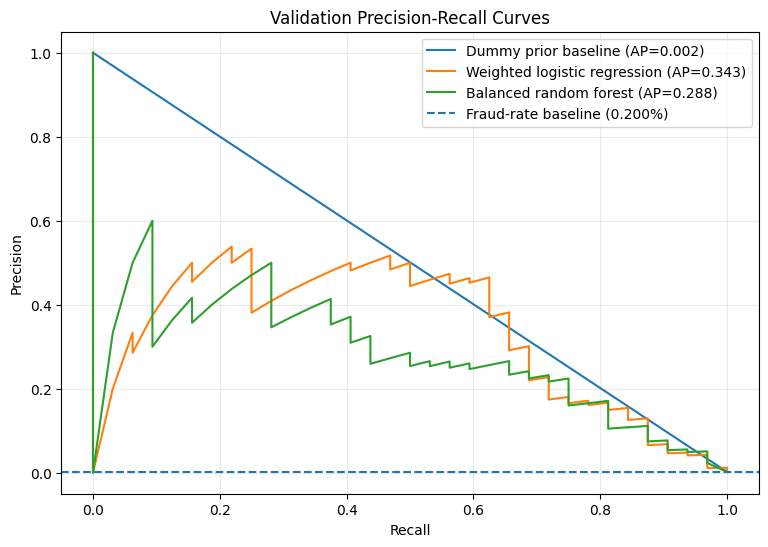

In [13]:
plt.figure(figsize=(9, 6))

for model_name, probabilities in validation_scores.items():
    precision, recall, _ = precision_recall_curve(
        y_validation,
        probabilities,
    )
    pr_auc = average_precision_score(
        y_validation,
        probabilities,
    )
    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP={pr_auc:.3f})",
    )

plt.axhline(
    y=y_validation.mean(),
    linestyle="--",
    label=f"Fraud-rate baseline ({y_validation.mean():.3%})",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [14]:
BEST_MODEL_NAME = model_comparison.iloc[0]["model"]
best_model = models[BEST_MODEL_NAME]
best_validation_probabilities = validation_scores[BEST_MODEL_NAME]

print("Selected model:", BEST_MODEL_NAME)

Selected model: Weighted logistic regression


## 8. Select the operating threshold

In [15]:
def find_threshold_table(
    y_true,
    probabilities,
    config: BusinessConfig,
    candidates: int = 50,
) -> pd.DataFrame:
    maximum_review_fraction = (
        config.daily_review_capacity
        / config.daily_transactions
    )

    review_fractions = np.linspace(
        0.00025,
        maximum_review_fraction,
        candidates,
    )

    thresholds = {
        float(np.quantile(probabilities, 1 - fraction))
        for fraction in review_fractions
    }

    # Include an operating point that creates no alerts.
    thresholds.add(
        float(np.nextafter(probabilities.max(), np.inf))
    )

    rows = []

    for threshold in thresholds:
        metrics = custom_binary_metrics(
            y_true,
            probabilities,
            threshold,
        )
        cost = estimate_daily_cost(
            metrics,
            len(y_true),
            config,
        )

        rows.append({
            **metrics,
            **cost,
            "within_capacity": (
                cost["estimated_daily_reviews"]
                <= config.daily_review_capacity + 1
            ),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("estimated_daily_total_cost_bdt")
        .reset_index(drop=True)
    )


threshold_table = find_threshold_table(
    y_validation,
    best_validation_probabilities,
    CONFIG,
)

threshold_table.head(10)[[
    "threshold",
    "precision",
    "recall",
    "estimated_daily_reviews",
    "estimated_daily_tp",
    "estimated_daily_fp",
    "estimated_daily_fn",
    "estimated_daily_total_cost_bdt",
    "within_capacity",
]]

,threshold,precision,recall,estimated_daily_reviews,estimated_daily_tp,estimated_daily_fp,estimated_daily_fn,estimated_daily_total_cost_bdt,within_capacity
0,0.9990,0.4737,0.5625,"4,750.0000","2,250.0000","2,500.0000","1,750.0000","54,062,500.0000",True
1,0.9992,0.4737,0.5625,"4,750.0000","2,250.0000","2,500.0000","1,750.0000","54,062,500.0000",True
2,0.9989,0.4615,0.5625,"4,875.0000","2,250.0000","2,625.0000","1,750.0000","54,112,500.0000",True
3,0.9988,0.4500,0.5625,"5,000.0000","2,250.0000","2,750.0000","1,750.0000","54,162,500.0000",True
4,0.9989,0.4500,0.5625,"5,000.0000","2,250.0000","2,750.0000","1,750.0000","54,162,500.0000",True
5,0.9993,0.4595,0.5312,"4,625.0000","2,125.0000","2,500.0000","1,875.0000","57,781,250.0000",True
6,0.9998,0.5000,0.5000,"4,000.0000","2,000.0000","2,000.0000","2,000.0000","61,300,000.0000",True
7,0.9998,0.5000,0.5000,"4,000.0000","2,000.0000","2,000.0000","2,000.0000","61,300,000.0000",True
8,0.9998,0.4848,0.5000,"4,125.0000","2,000.0000","2,125.0000","2,000.0000","61,350,000.0000",True
9,0.9998,0.4706,0.5000,"4,250.0000","2,000.0000","2,250.0000","2,000.0000","61,400,000.0000",True


In [16]:
operational_rows = threshold_table[
    threshold_table["within_capacity"]
].copy()

selected_row = operational_rows.iloc[0]
SELECTED_THRESHOLD = float(selected_row["threshold"])

print(f"Selected threshold: {SELECTED_THRESHOLD:.6f}")
print(f"Validation precision: {selected_row['precision']:.2%}")
print(f"Validation recall: {selected_row['recall']:.2%}")
print(
    "Estimated daily reviews:",
    f"{selected_row['estimated_daily_reviews']:,.0f}",
)

Selected threshold: 0.999019
Validation precision: 47.37%
Validation recall: 56.25%
Estimated daily reviews: 4,750


The threshold is selected from validation data by balancing:

- Fraud missed
- Legitimate alerts
- Investigation cost
- Customer-friction cost
- Daily review capacity

A production bank may use multiple thresholds:

| Risk level | Suggested action |
|---|---|
| Low | Approve |
| Medium | OTP or step-up verification |
| High | Manual review |
| Very high | Temporary block |

## 9. Final test evaluation

In [17]:
test_probabilities = best_model.predict_proba(X_test)[:, 1]

test_metrics = custom_binary_metrics(
    y_test,
    test_probabilities,
    SELECTED_THRESHOLD,
)

test_cost = estimate_daily_cost(
    test_metrics,
    len(y_test),
    CONFIG,
)

test_result = pd.Series({
    "PR_AUC": average_precision_score(
        y_test,
        test_probabilities,
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        test_probabilities,
    ),
    "Brier_score": brier_score_loss(
        y_test,
        test_probabilities,
    ),
    **test_metrics,
    **test_cost,
})

test_result

PR_AUC                                    0.3968
ROC_AUC                                   0.9940
Brier_score                               0.0262
threshold                                 0.9990
tn                                   15,939.0000
fp                                       29.0000
fn                                       19.0000
tp                                       13.0000
precision                                 0.3095
recall                                    0.4062
specificity                               0.9982
f1                                        0.3514
flagged_count                            42.0000
flag_rate                                 0.0026
estimated_daily_tp                    1,625.0000
estimated_daily_fp                    3,625.0000
estimated_daily_fn                    2,375.0000
estimated_daily_reviews               5,250.0000
estimated_daily_total_cost_bdt   73,106,250.0000
dtype: float64

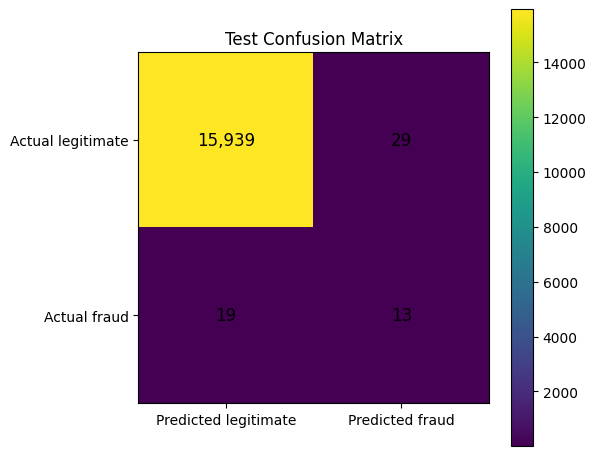

In [18]:
matrix = np.array([
    [test_metrics["tn"], test_metrics["fp"]],
    [test_metrics["fn"], test_metrics["tp"]],
])

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(matrix)

for row in range(2):
    for column in range(2):
        ax.text(
            column,
            row,
            f"{matrix[row, column]:,}",
            ha="center",
            va="center",
            fontsize=12,
        )

ax.set_xticks(
    [0, 1],
    labels=["Predicted legitimate", "Predicted fraud"],
)
ax.set_yticks(
    [0, 1],
    labels=["Actual legitimate", "Actual fraud"],
)
ax.set_title("Test Confusion Matrix")
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

## 10. Estimate the business benefit

In [19]:
expected_daily_fraud = (
    CONFIG.daily_transactions
    * CONFIG.expected_fraud_rate
)

daily_loss_without_model = (
    expected_daily_fraud
    * CONFIG.average_missed_fraud_loss_bdt
)

daily_cost_with_model = (
    test_cost["estimated_daily_total_cost_bdt"]
)

estimated_daily_savings = (
    daily_loss_without_model
    - daily_cost_with_model
)

business_outcome = pd.Series({
    "Expected daily fraud cases": expected_daily_fraud,
    "Estimated fraud detected daily": test_cost["estimated_daily_tp"],
    "Estimated fraud missed daily": test_cost["estimated_daily_fn"],
    "Estimated legitimate alerts daily": test_cost["estimated_daily_fp"],
    "Estimated daily reviews": test_cost["estimated_daily_reviews"],
    "Loss without model (BDT/day)": daily_loss_without_model,
    "Cost with model (BDT/day)": daily_cost_with_model,
    "Estimated savings (BDT/day)": estimated_daily_savings,
    "Estimated savings (BDT/year)": estimated_daily_savings * 365,
})

business_outcome

Expected daily fraud cases                   4,000.0000
Estimated fraud detected daily               1,625.0000
Estimated fraud missed daily                 2,375.0000
Estimated legitimate alerts daily            3,625.0000
Estimated daily reviews                      5,250.0000
Loss without model (BDT/day)           120,000,000.0000
Cost with model (BDT/day)               73,106,250.0000
Estimated savings (BDT/day)             46,893,750.0000
Estimated savings (BDT/year)        17,116,218,750.0000
dtype: float64

### Expected benefits

After deployment, the bank can gain:

1. Lower direct fraud losses
2. Faster fraud identification
3. Better prioritization of investigators
4. Fewer unnecessary alerts than broad static rules
5. More consistent risk decisions
6. Measurable daily and annual financial impact
7. A reusable risk score for approval, verification, review, and blocking

## 11. Performance by merchant segment

In [20]:
def segment_metrics(
    original_data: pd.DataFrame,
    y_true,
    probabilities,
    threshold: float,
    segment_column: str,
) -> pd.DataFrame:
    evaluation = original_data[[segment_column]].copy()
    evaluation["actual"] = np.asarray(y_true)
    evaluation["score"] = np.asarray(probabilities)

    rows = []

    for segment, group in evaluation.groupby(segment_column):
        metrics = custom_binary_metrics(
            group["actual"],
            group["score"],
            threshold,
        )

        rows.append({
            "segment": segment,
            "transactions": len(group),
            "actual_fraud": int(group["actual"].sum()),
            "fraud_rate": group["actual"].mean(),
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "flag_rate": metrics["flag_rate"],
        })

    return pd.DataFrame(rows).sort_values(
        "transactions",
        ascending=False,
    )


segment_metrics(
    test_df,
    y_test,
    test_probabilities,
    SELECTED_THRESHOLD,
    "merchant_category",
)

,segment,transactions,actual_fraud,fraud_rate,precision,recall,flag_rate
4,grocery,3864,3,0.0008,0.1667,0.3333,0.0016
6,restaurant,2923,5,0.0017,0.4444,0.8000,0.0031
5,healthcare,2374,2,0.0008,0.0000,0.0000,0.0004
3,fuel,1739,0,0.0000,0.0000,0.0000,0.0006
2,electronics,1490,6,0.0040,0.2857,0.3333,0.0047
0,cash_withdrawal,1306,3,0.0023,0.2000,0.3333,0.0038
1,digital_goods,1253,12,0.0096,0.3636,0.3333,0.0088
7,travel,1051,1,0.0010,0.5000,1.0000,0.0019


## 12. Feature importance

In [21]:
transformed_feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

estimator = best_model.named_steps["model"]

if hasattr(estimator, "feature_importances_"):
    importance_values = estimator.feature_importances_
elif hasattr(estimator, "coef_"):
    importance_values = np.abs(estimator.coef_[0])
else:
    importance_values = np.zeros(
        len(transformed_feature_names)
    )

feature_importance = (
    pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": importance_values,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(15)

,feature,importance
0,device_type_atm,4.0405
1,merchant_category_fuel,3.6203
2,merchant_category_digital_goods,2.8846
3,merchant_category_healthcare,2.8773
4,international,1.9554
5,merchant_category_grocery,1.6688
6,device_type_pos,1.4787
7,merchant_category_cash_withdrawal,1.3912
8,new_device,1.3601
9,merchant_category_restaurant,1.2059


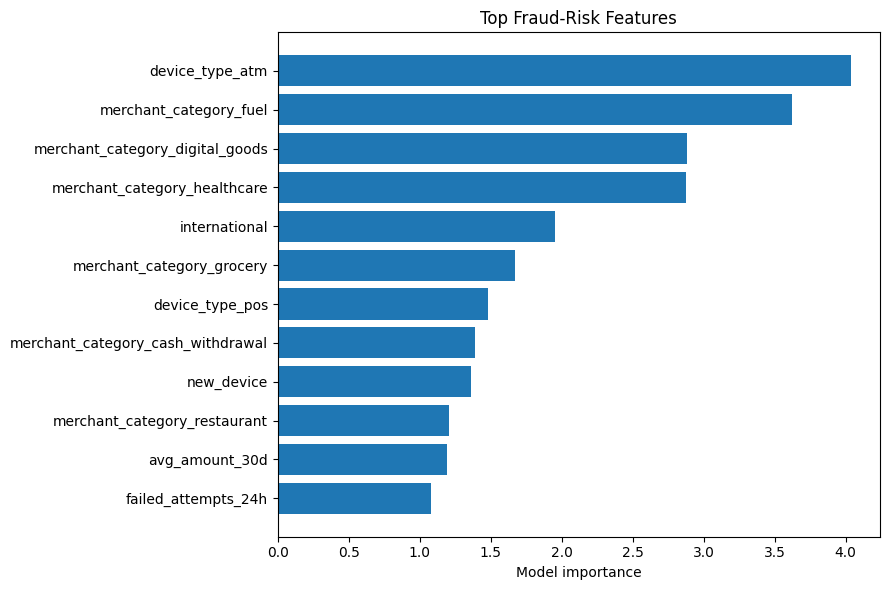

In [22]:
top_features = feature_importance.head(12).sort_values(
    "importance",
    ascending=True,
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["feature"],
    top_features["importance"],
)
plt.xlabel("Model importance")
plt.title("Top Fraud-Risk Features")
plt.tight_layout()
plt.show()

## 13. Reusable transaction-scoring function

In [23]:
def score_transactions(
    model: Pipeline,
    transaction_batch: pd.DataFrame,
    threshold: float,
) -> pd.DataFrame:
    missing_features = sorted(
        set(FEATURES) - set(transaction_batch.columns)
    )

    if missing_features:
        raise ValueError(
            f"Missing required features: {missing_features}"
        )

    probabilities = model.predict_proba(
        transaction_batch[FEATURES]
    )[:, 1]

    result = transaction_batch.copy()
    result["fraud_probability"] = probabilities
    result["fraud_alert"] = probabilities >= threshold

    result["recommended_action"] = pd.cut(
        probabilities,
        bins=[
            -np.inf,
            threshold * 0.50,
            threshold,
            np.inf,
        ],
        labels=[
            "approve",
            "step_up_verification",
            "manual_review",
        ],
    )

    return result.sort_values(
        "fraud_probability",
        ascending=False,
    )


sample_scores = score_transactions(
    best_model,
    test_df.head(20),
    SELECTED_THRESHOLD,
)

sample_scores[[
    "transaction_id",
    "amount",
    "merchant_category",
    "new_device",
    "international",
    "fraud_probability",
    "fraud_alert",
    "recommended_action",
    "is_fraud",
]]

,transaction_id,amount,merchant_category,new_device,international,fraud_probability,fraud_alert,recommended_action,is_fraud
64002,TX-000064003,266.2883,restaurant,0,1,0.9718,False,step_up_verification,0
64017,TX-000064018,317.7825,travel,1,0,0.8909,False,step_up_verification,0
64010,TX-000064011,8.5039,digital_goods,0,1,0.8582,False,step_up_verification,0
64007,TX-000064008,6.6546,digital_goods,1,0,0.0967,False,approve,0
64013,TX-000064014,76.1123,digital_goods,0,0,0.0095,False,approve,0
64006,TX-000064007,34.5995,digital_goods,0,0,0.0052,False,approve,0
64019,TX-000064020,43.1685,grocery,0,0,0.0042,False,approve,0
64003,TX-000064004,26.5330,digital_goods,0,0,0.0029,False,approve,0
64012,TX-000064013,321.4386,electronics,0,0,0.0020,False,approve,0
64009,TX-000064010,18.6808,cash_withdrawal,0,0,0.0008,False,approve,0


## 14. Basic drift monitoring

In [24]:
def population_stability_index(
    reference,
    current,
    bins: int = 10,
    epsilon: float = 1e-6,
) -> float:
    reference = np.asarray(reference, dtype=float)
    current = np.asarray(current, dtype=float)

    boundaries = np.unique(
        np.quantile(
            reference,
            np.linspace(0, 1, bins + 1),
        )
    )

    if len(boundaries) < 3:
        return 0.0

    boundaries[0] = -np.inf
    boundaries[-1] = np.inf

    reference_counts, _ = np.histogram(
        reference,
        bins=boundaries,
    )
    current_counts, _ = np.histogram(
        current,
        bins=boundaries,
    )

    reference_ratio = np.clip(
        reference_counts / reference_counts.sum(),
        epsilon,
        None,
    )
    current_ratio = np.clip(
        current_counts / current_counts.sum(),
        epsilon,
        None,
    )

    return float(np.sum(
        (current_ratio - reference_ratio)
        * np.log(current_ratio / reference_ratio)
    ))


train_probabilities = best_model.predict_proba(
    X_train
)[:, 1]

monitoring_summary = pd.Series({
    "Prediction score PSI": population_stability_index(
        train_probabilities,
        test_probabilities,
    ),
    "Transaction amount PSI": population_stability_index(
        train_df["amount"],
        test_df["amount"],
    ),
})

monitoring_summary

Prediction score PSI     0.0004
Transaction amount PSI   0.0009
dtype: float64

### Production monitoring checklist

Monitor:

- Prediction latency
- API failures
- Missing features
- New categories
- Alert volume
- Score distribution
- Feature drift
- Precision and recall after labels arrive
- Fraud loss
- False decline rate
- Performance by customer and transaction segment

Do not retrain automatically until the cause of performance degradation is understood.

## 15. Production architecture

```text
Incoming transaction
        |
        v
Real-time feature service
        |
        v
Fraud-scoring API
        |
        v
Fraud probability and risk tier
        |
        v
Decision engine
  |          |             |
Approve   Verify OTP   Review / temporary block
        |
        v
Investigation and chargeback outcomes
        |
        v
Label store, monitoring, and retraining
```

### Production controls

- Shared training and serving feature definitions
- Model, feature, and dataset versioning
- Unit and integration tests
- Shadow deployment
- Canary release
- Rollback support
- Access control
- Audit logs
- Human override
- Privacy and regulatory review

## 16. Important limitations

A real bank system must improve this demonstration by:

1. Replacing synthetic data with approved historical data
2. Handling delayed fraud labels
3. Separating different fraud types
4. Adding graph relationships between cards, devices, accounts, merchants, and IP addresses
5. Calibrating probabilities
6. Using transaction-specific expected loss
7. Adding investigator explanations
8. Testing fairness and customer impact
9. Using champion-challenger deployment
10. Performing security, privacy, governance, and regulatory reviews

## 17. Interview questions based on this project

1. Why is 99.8% accuracy misleading?
2. Why is a chronological split necessary?
3. How can post-transaction information create leakage?
4. How should the threshold change when review capacity decreases?
5. Why can higher recall produce lower business value?
6. Why should automatic blocking use a higher threshold than manual review?
7. How would you evaluate the model when confirmed labels arrive after 30 days?
8. How would you respond when production precision drops?
9. How would graph features detect coordinated fraud?
10. How would you deploy the model without immediately affecting customers?